# Monitor the training process -- Weather Prediction (PyTorch)

We work on a regression task (weather prediction):
- how to create a neural network
- how to optimize the model
- how to monitor the training process
- how to detect (or avoid) overfitting
- common options to improve the model performance

## 0. Import packages and modules

Enable Array-API support globally to reduce need for data movement between devices and for scikit-learn to better support PyTorch tensors.

In [1]:
import os

os.environ["SCIPY_ARRAY_API"] = "1"

import sklearn
sklearn.set_config(array_api_dispatch=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

import torch
import torch.nn as nn

print(f"PyTorch version: {torch.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

# Check if GPU is available
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

PyTorch version: 2.10.0+cu128
Sklearn version: 1.8.0
Using cpu device


/home/ashwinmo/Sources/mimer-ai/deep-learning-intro/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1.Formulate/Outline the problem: Weather Prediction

<img src="https://learn.mimer-ai.eu/deep-learning-intro/_images/03_weather_prediction_dataset_map.png" alt="drawing" width="720"/>

## 2. Identify inputs and outputs

In [3]:
data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")
data

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,20091228,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,...,-15.1,-16.2,-14.0,0.95,1.0011,0.22,1.50,6.2,1.8,10.6
3650,20091229,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,...,-10.9,-14.4,-7.3,0.89,0.9966,0.24,0.40,10.4,6.2,14.5
3651,20091230,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,...,-6.6,-7.6,-5.6,0.88,0.9939,0.24,1.00,10.0,8.7,11.3
3652,20091231,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,...,-7.2,-8.9,-5.4,0.88,0.9933,0.58,0.02,8.5,6.2,10.9


In [4]:
data.describe()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,3.654000e+03,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,...,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000
mean,2.004568e+07,6.520799,5.418446,0.745107,1.017876,1.330380,0.234849,4.661193,11.022797,6.989135,...,-4.626327,-6.884319,-2.352244,0.781872,1.016639,1.369787,0.186100,12.205802,7.860536,16.551779
std,2.874287e+04,3.450083,2.325497,0.107788,0.007962,0.935348,0.536267,4.330112,7.414754,6.653356,...,6.987080,7.120333,6.972886,0.115572,0.018885,0.926472,0.422151,6.467155,5.692256,7.714924
min,2.000010e+07,1.000000,0.000000,0.380000,0.985600,0.050000,0.000000,0.000000,-9.300000,-16.000000,...,-26.600000,-30.300000,-24.700000,0.330000,0.000300,0.050000,0.000000,-6.200000,-13.000000,-3.100000
25%,2.002070e+07,4.000000,4.000000,0.670000,1.013300,0.530000,0.000000,0.500000,5.300000,2.000000,...,-9.400000,-11.800000,-7.100000,0.700000,1.012100,0.550000,0.000000,7.600000,3.700000,10.800000
50%,2.004567e+07,7.000000,6.000000,0.760000,1.017700,1.110000,0.000000,3.600000,11.400000,7.300000,...,-4.400000,-6.400000,-2.200000,0.800000,1.017300,1.235000,0.000000,12.300000,8.300000,16.600000
75%,2.007070e+07,10.000000,7.000000,0.830000,1.022700,2.060000,0.210000,8.000000,16.900000,12.400000,...,0.700000,-1.100000,2.700000,0.870000,1.022200,2.090000,0.160000,17.200000,12.300000,22.400000
max,2.010010e+07,12.000000,8.000000,0.980000,1.040800,3.550000,7.570000,15.300000,29.000000,20.800000,...,13.800000,8.700000,14.300000,1.000000,1.041400,3.560000,6.200000,31.200000,22.600000,39.800000


In [5]:
data.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW_pressure', 'HEATHROW_global_radiation',
       'HEATH

In [6]:
data.shape

(3654, 91)

## 3. Prepare data

### 3.1 Select a subset and split into data and y_batch

In [119]:
nr_rows = 365*3 # 3 years

# data
X_data = data.loc[:nr_rows] # Select first 3 years
X_data = X_data.drop(columns=['DATE', 'MONTH']) # Drop date and month column

# y_batch (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

### 3.2 Split data and y_batch into training, validation, and test set

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

### 3.3 Prepare datasets and dataloaders (PyTorch only)

In [121]:
from torch.utils.data import TensorDataset, DataLoader


train_dataset = TensorDataset(
    torch.tensor(X_train.values, dtype=torch.float),
    torch.tensor(y_train.values, dtype=torch.float)
)
# NOTE: we will use the validation dataset later
test_dataset = TensorDataset(
    torch.tensor(X_test.values, dtype=torch.float),
    torch.tensor(y_test.values, dtype=torch.float)
)


train_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 4. Building architecture from scratch

### 4.1 Build the neuron network

In [106]:
import torch.nn.functional as F


class WeatherPredictionModel(nn.Module):
    def __init__(self, input_shape, hidden1=100, hidden2=50):
        super().__init__()

        self.hidden_layer1 = nn.Linear(input_shape, hidden1)
        self.hidden_layer2 = nn.Linear(hidden1, hidden2)
        self.output_layer = nn.Linear(hidden2, 1)
    
    def forward(self, x):
        x = self.hidden_layer1(x)
        x = F.relu(x)
        x = self.hidden_layer2(x)
        x = F.relu(x)
        x = self.output_layer(x)
        return x

model = WeatherPredictionModel(X_train.shape[1])

In [11]:
# summary of the model
print(model)

WeatherPredictionModel(
  (hidden_layer1): Linear(in_features=89, out_features=100, bias=True)
  (hidden_layer2): Linear(in_features=100, out_features=50, bias=True)
  (output_layer): Linear(in_features=50, out_features=1, bias=True)
)


In [12]:
from torchinfo import summary

example_batch_size = 32
summary(model, input_size=(example_batch_size, X_train.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
WeatherPredictionModel                   [32, 1]                   --
├─Linear: 1-1                            [32, 100]                 9,000
├─Linear: 1-2                            [32, 50]                  5,050
├─Linear: 1-3                            [32, 1]                   51
Total params: 14,101
Trainable params: 14,101
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.45
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.06
Estimated Total Size (MB): 0.11

### 4.2 Gradient descent

<img src="https://editor.analyticsvidhya.com/uploads/93873gd1.png" alt="drawing" width="400"/> <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*HJifIvvsZpQdGEenC8w-Qg.jpeg" alt="drawing" width="350"/>

**Gradient Descent** (GD) is an optimization algorithm used to find the minimum of a function
- `gradient` means an increase and decrease in a property (LOSS function)
- `descent` means the action of moving downwards
- GD means to update the parameters (weights and biases) against the direction of the gradient, so as to find the minimum of the dependent function (the loss function)

**GD** has lots of variations
- **Stochastic Gradient Descent (SGD)**
    - SGD only uses a one sample of the training dataset to update the model parameters
- **Batch Gradient Descent**
    - it computes the gradient of loss function using entire training dataset in one epoch
- **Mini-Batch Gradient Descent**, a variant of SGD, is commonly used
    - gradients are computed over small subsets of data to combine the benefits of both methods—stability from batch processing and efficiency from stochastic updates
    - this subset is called `batch`
    - the number of samples in one batch is called `batch size` (*e.g.*, 32 or 64 samples)

<img src="https://enccs.github.io/deep-learning-intro/_images/03_gradient_descent.png" alt="drawing" width="600"/>

**learning rate** is a parameter in GD algorithm
- it controls how big a step we should take to decrease a property (LOSS function)
- if it is too small, training is very slow and might get stuck in local minima
- it it is too large, training might overshoot the minimum or even diverge
- a better way is to adjust learning rate over time
- the **Adam** optimizer (Adaptive Moment Estimation)
    - it combines momentum + adaptive learning rate
    - momentum means to add a velocity term to smooth updates and escape local minima

## 5. Choose a loss function and optimizer

In [13]:
# loss function, optimizer
import torch.optim as optim

optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

## 6. Train the model

In [61]:
from tqdm import tqdm
from sklearn import metrics


def train_epoch(model, data_loader, loss_fn, optimizer, progress_desc):
    """Training the model for one epoch."""
    model.train()
    running_loss = 0.0
    running_rmse = 0.0

    if progress_desc:
        pbar = tqdm(data_loader, desc=progress_desc)
    else:
        pbar = data_loader

    for i, (X_batch, y_batch) in enumerate(pbar):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Zero the gradients
        optimizer.zero_grad()
  
        # Forward pass and make predictions
        y_pred = model(X_batch)

        # Compute loss
        loss = loss_fn(y_pred.squeeze(), y_batch)
        
        # Backward pass and update weights using the optimizer
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_rmse += metrics.root_mean_squared_error(y_batch, y_pred)

        if progress_desc:
            pbar.set_postfix({"loss": running_loss / (i + 1), "rmse": running_rmse / (i + 1)})
    
    train_loss = running_loss / len(data_loader)
    train_rmse = running_rmse / len(data_loader)
    # print(f"{train_loss = }, {train_rmse = }")
    return train_loss, train_rmse

def eval_epoch(model, data_loader, loss_fn, accumulate=False):
    """Evaluate the model for one epoch for testing / validation data. 
    No gradients are computed, no backpropagation.
    
    """
    model.eval()
    running_loss = 0.0
    running_rmse = 0.0
    y_true_tensor = torch.tensor([])
    y_pred_tensor = torch.tensor([])

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = loss_fn(y_pred.squeeze(), y_batch)

            running_loss += loss.item()
            running_rmse += metrics.root_mean_squared_error(y_batch, y_pred)

            if accumulate:
                y_true_tensor = torch.cat((y_true_tensor, y_batch))
                y_pred_tensor = torch.cat((y_pred_tensor, y_pred))
    
    eval_loss = running_loss / len(data_loader)
    eval_rmse = running_rmse / len(data_loader)
    return eval_loss, eval_rmse, y_true_tensor, y_pred_tensor

In [15]:
model = model.to(device)

history = {'loss': [], 'root_mean_squared_error': []}
epochs = 200

for epoch in range(epochs):
    loss, rmse = train_epoch(model, train_dl, loss_fn, optimizer, f"Epoch {epoch+1}/{epochs}")
    history['loss'].append(loss)
    history['root_mean_squared_error'].append(rmse)


Epoch 200/200: 100%|██████████| 24/24 [00:01<00:00, 21.60it/s, loss=0.693, rmse=0.815]


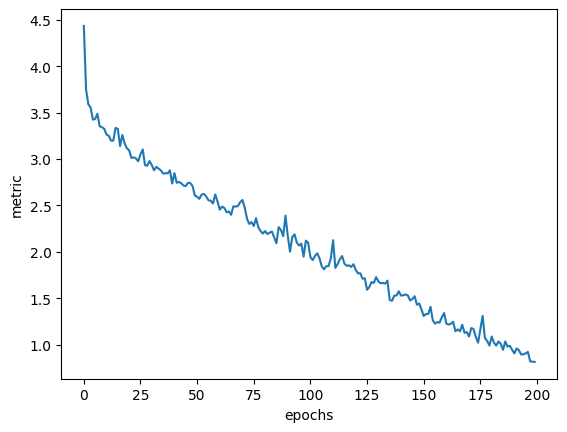

In [17]:
def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (dict): Dictionary containing training history
        metrics (str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame(history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")

plot_history(history, 'root_mean_squared_error')

## 7. Perform a prediction/classification

In [ ]:
_, train_rmse, y_train_true, y_train_predicted = eval_epoch(model, train_dl, loss_fn, accumulate=True)
_, test_rmse, y_test_true, y_test_predicted = eval_epoch(model, test_dl, loss_fn, accumulate=True)

## 8. Measure performance

### 8.1 Measure performance of the trained model

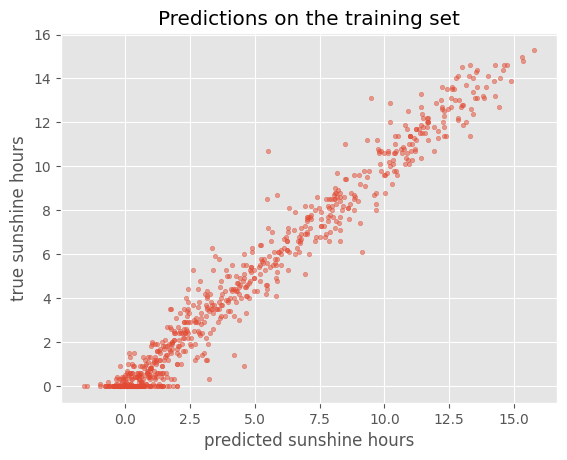

In [43]:
def plot_predictions(y_pred, y_true, title):
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    plt.scatter(y_pred, y_true, s=10, alpha=0.5)
    plt.xlabel("predicted sunshine hours")
    plt.ylabel("true sunshine hours")
    plt.title(title)

plot_predictions(y_train_predicted, y_train_true, title='Predictions on the training set')

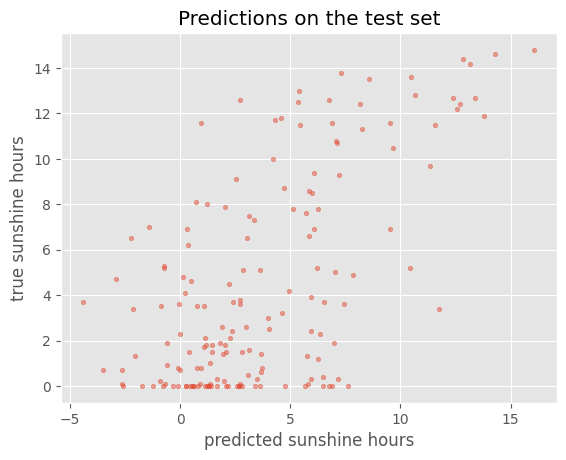

In [44]:
plot_predictions(y_test_predicted, y_test_true, title='Predictions on the test set')

In [46]:
print(f'Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}')

Train RMSE: 0.78, Test RMSE: 3.93


### 8.2 The baseline model

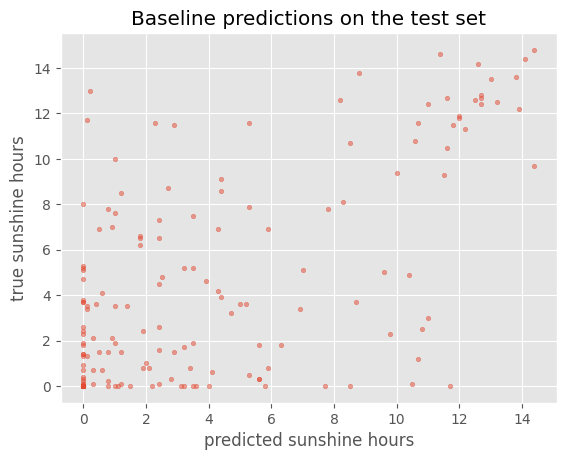

In [47]:
# Baseline prediction using previous day's sunshine hours
y_baseline_prediction = X_test['BASEL_sunshine'].values
plot_predictions(y_baseline_prediction, y_test, title='Baseline predictions on the test set')

In [48]:
from sklearn.metrics import root_mean_squared_error

rmse_baseline = root_mean_squared_error(y_test, y_baseline_prediction)
print('Baseline:', rmse_baseline)
print('Neural network: ', test_rmse)

Baseline: 3.877323350410224
Neural network:  3.931880474090576


## 9. Refine the model

### 9.1 The validation dataset

In [122]:
val_dataset = TensorDataset(
    torch.tensor(X_val.values, dtype=torch.float),
    torch.tensor(y_val.values, dtype=torch.float)
)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
model = WeatherPredictionModel(input_shape=X_data.shape[1])
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

In [ ]:
model = model.to(device)

history = {
    'loss': [],
    'root_mean_squared_error': [],
    'val_loss': [],
    'val_root_mean_squared_error': []
}
epochs = 200

for epoch in range(epochs):
    loss, rmse = train_epoch(model, train_dl, loss_fn, optimizer, False)
    history['loss'].append(loss)
    history['root_mean_squared_error'].append(rmse)

    val_loss, val_rmse, *_ = eval_epoch(model, val_dl, loss_fn)
    history['val_loss'].append(val_loss)
    history['val_root_mean_squared_error'].append(val_rmse)

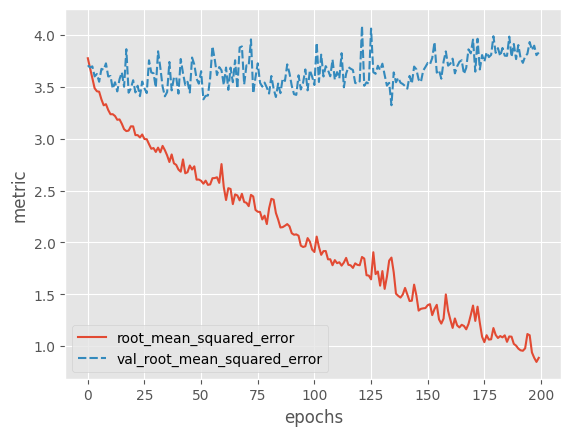

In [57]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

### 9.2 Counteract model overfitting

#### 9.2.1 Reduce number of parameters

In [69]:
# Create smaller model
model = WeatherPredictionModel(input_shape=X_data.shape[1], hidden1=10, hidden2=5)
summary(model, input_size=(32, X_data.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
WeatherPredictionModel                   [32, 1]                   --
├─Linear: 1-1                            [32, 10]                  900
├─Linear: 1-2                            [32, 5]                   55
├─Linear: 1-3                            [32, 1]                   6
Total params: 961
Trainable params: 961
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.01
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.02

In [65]:
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

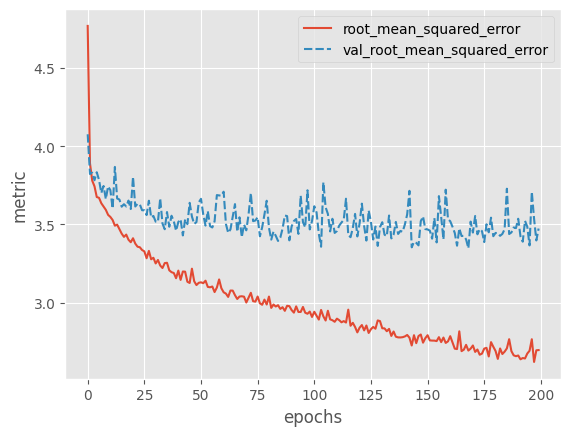

In [66]:
model = model.to(device)

history = {
    'loss': [],
    'root_mean_squared_error': [],
    'val_loss': [],
    'val_root_mean_squared_error': []
}
epochs = 200

for epoch in range(epochs):
    loss, rmse = train_epoch(model, train_dl, loss_fn, optimizer, False)
    history['loss'].append(loss)
    history['root_mean_squared_error'].append(rmse)

    val_loss, val_rmse, *_ = eval_epoch(model, val_dl, loss_fn)
    history['val_loss'].append(val_loss)
    history['val_root_mean_squared_error'].append(val_rmse)

plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

#### 9.2.2 Early stopping: stop when things are looking best

In [123]:
model = WeatherPredictionModel(input_shape=X_data.shape[1])
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

In [ ]:
def fit(model, train_dl, loss_fn, optimizer, val_dl):
    model = model.to(device)

    history = {
        'loss': [],
        'root_mean_squared_error': [],
        'val_loss': [],
        'val_root_mean_squared_error': []
    }
    epochs = 200
    early_stopping_patience = 10

    best_val_loss = float('inf')
    patience_counter = 0
        
    for epoch in range(epochs):
        loss, rmse = train_epoch(
            model,
            train_dl,
            loss_fn,
            optimizer,
            f"Epoch {epoch+1}/{epochs} {best_val_loss=:.2f}"
        )
        history['loss'].append(loss)
        history['root_mean_squared_error'].append(rmse)

        val_loss, val_rmse, *_ = eval_epoch(model, val_dl, loss_fn)
        history['val_loss'].append(val_loss)
        history['val_root_mean_squared_error'].append(val_rmse)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1}')
                # Restore best model
                model.load_state_dict(best_model_state)
                break
        
    return model, history

model, history = fit(model, train_dl, loss_fn, optimizer, val_dl)

Epoch 1/200 best_val_loss=inf:   4%|▍         | 1/24 [00:00<00:03,  6.22it/s, loss=31.8, rmse=5.62]

Epoch 27/200 best_val_loss=11.97: 100%|██████████| 24/24 [00:01<00:00, 20.35it/s, loss=9.27, rmse=3.03]


Early stopping at epoch 27


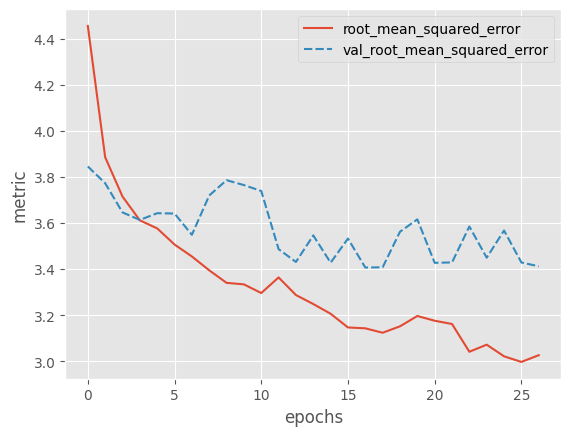

In [125]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

#### 9.2.3 BatchNorm: the `standard scaler` for deep learning

In [129]:
class WeatherPredictionModelBatchNorm(nn.Module):
    def __init__(self, input_shape, hidden1=100, hidden2=50):
        super().__init__()
        self.batch_norm = nn.BatchNorm1d(input_shape)
        self.hidden_layer1 = nn.Linear(input_shape, hidden1)
        self.hidden_layer2 = nn.Linear(hidden1, hidden2)
        self.output_layer = nn.Linear(hidden2, 1)
    
    def forward(self, x):
        x = self.batch_norm(x)
        x = self.hidden_layer1(x)
        x = F.relu(x)
        x = self.hidden_layer2(x)
        x = F.relu(x)
        x = self.output_layer(x)
        return x

model = WeatherPredictionModel(X_train.shape[1])
summary(model, input_size=(32, X_train.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
WeatherPredictionModel                   [32, 1]                   --
├─Linear: 1-1                            [32, 100]                 9,000
├─Linear: 1-2                            [32, 50]                  5,050
├─Linear: 1-3                            [32, 1]                   51
Total params: 14,101
Trainable params: 14,101
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.45
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.06
Estimated Total Size (MB): 0.11

In [130]:
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

In [131]:
model, history = fit(model, train_dl, loss_fn, optimizer, val_dl)

Epoch 37/200 best_val_loss=11.45: 100%|██████████| 24/24 [00:01<00:00, 20.62it/s, loss=8.47, rmse=2.88]


Early stopping at epoch 37


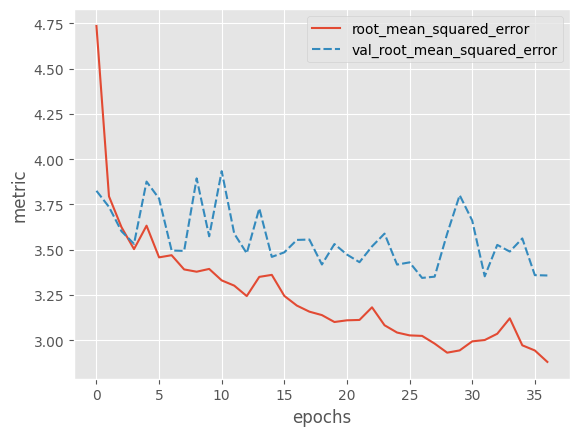

In [132]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [133]:
_, test_rmse, y_test_true, y_test_predicted = eval_epoch(model, test_dl, loss_fn, accumulate=True)

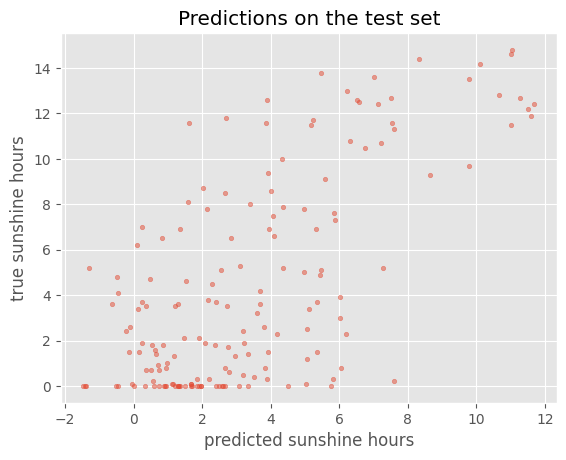

In [134]:
plot_predictions(y_test_predicted, y_test_true, title='Predictions on the test set')

In [135]:
print('Baseline:', rmse_baseline)
print('Test RMSE:', test_rmse)

Baseline: 3.877323350410224
Test RMSE: 3.8387778600056968


### 9.3 Simplify the model and add data

In [136]:
cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]

In [137]:
# use 9 years out of the dataset

nr_rows = 365*9
# data
X_data = data.loc[:nr_rows].drop(columns=['DATE', 'MONTH'])

# y_batch (sunshine hours the next day)
y_data = data.loc[1:(nr_rows + 1)]["BASEL_sunshine"]

In [138]:
# only use columns with 'BASEL'

cols = [c for c in X_data.columns if c[:5] == 'BASEL']
X_data = X_data[cols]

In [139]:
# Rerun the model and evaluate it

X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

In [140]:
X_train.shape

(2300, 9)

In [141]:
train_dataset = TensorDataset(
    torch.tensor(X_train.values, dtype=torch.float),
    torch.tensor(y_train.values, dtype=torch.float)
)
test_dataset = TensorDataset(
    torch.tensor(X_test.values, dtype=torch.float),
    torch.tensor(y_test.values, dtype=torch.float)
)
val_dataset = TensorDataset(
    torch.tensor(X_val.values, dtype=torch.float),
    torch.tensor(y_val.values, dtype=torch.float)
)

train_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [148]:
model = WeatherPredictionModelBatchNorm(input_shape=X_data.shape[1])
summary(model, (32, X_train.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
WeatherPredictionModelBatchNorm          [32, 1]                   --
├─BatchNorm1d: 1-1                       [32, 9]                   18
├─Linear: 1-2                            [32, 100]                 1,000
├─Linear: 1-3                            [32, 50]                  5,050
├─Linear: 1-4                            [32, 1]                   51
Total params: 6,119
Trainable params: 6,119
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.20
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.02
Estimated Total Size (MB): 0.07

In [149]:
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

In [150]:
model, history = fit(model, train_dl, loss_fn, optimizer, val_dl)

Epoch 41/200 best_val_loss=11.13: 100%|██████████| 72/72 [00:05<00:00, 13.08it/s, loss=11, rmse=3.3]   


Early stopping at epoch 41


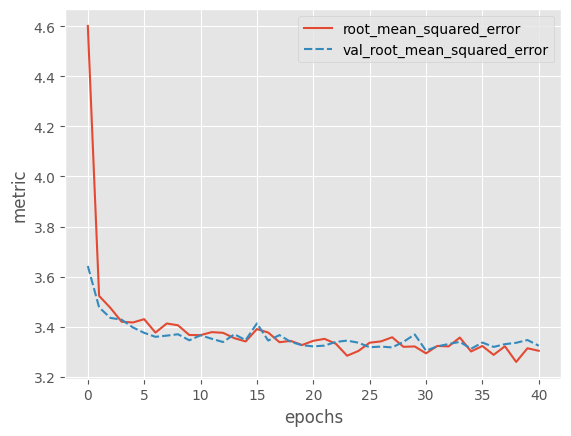

In [151]:
plot_history(history, ['root_mean_squared_error', 'val_root_mean_squared_error'])

In [145]:
_, test_rmse, y_test_true, y_test_predicted = eval_epoch(model, test_dl, loss_fn, accumulate=True)

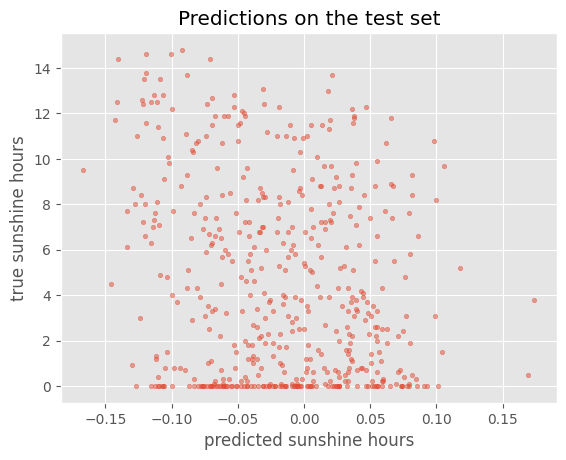

In [146]:
plot_predictions(y_test_predicted, y_test_true, title='Predictions on the test set')

In [147]:
print('Baseline:', rmse_baseline)
print('Test RMSE:', test_rmse)

Baseline: 3.877323350410224
Test RMSE: 6.120875805616379


### Using Tensorboard for experiment tracking

In [152]:
# TensorBoard logging
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter


log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)

def fit_with_tensorboard(model, train_loader, val_loader, optimizer, criterion, epochs=200, verbose=1):
    model = model.to(device)
    
    for epoch in range(epochs):
        # Training phase
        loss, rmse = train_epoch(
            model,
            train_dl,
            loss_fn,
            optimizer,
            f"Epoch {epoch+1}/{epochs} {val_loss=:.2f}"
        )
        writer.add_scalar('training loss', loss, epoch)

        # Validation phase
        val_loss, val_rmse = eval_epoch(model, val_loader, loss_fn)

        # Log to TensorBoard
        writer.add_scalar('validation loss', val_loss, epoch)
            
    writer.close()
    return model

# Example usage:
# fit_with_tensorboard(model, train_loader, val_loader, optimizer, criterion)

2026-02-16 01:23:34.476930: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 01:23:34.553002: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 01:23:36.557076: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 10. Save the model

In [ ]:
trained_model_path = "weather_prediction_model_pytorch.pt"
torch.save(model_final.state_dict(), trained_model_path)
print(f"Model saved to {trained_model_path}")